(-5.239505250000001,
 110.02961025000002,
 -3.0250297665079575,
 63.525625096667106)

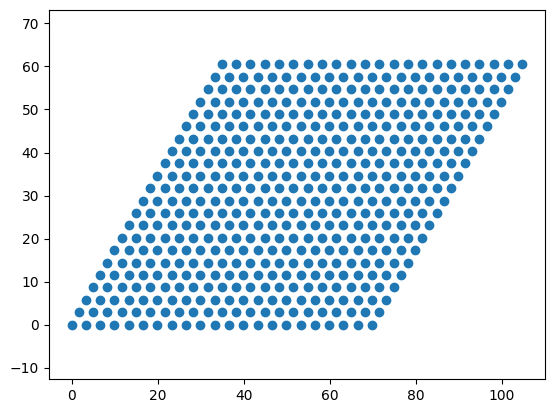

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.interpolate import griddata
from scipy import constants
from scipy.special import erfc
def fit_f(angle,a1,b1,a2,b2,f1):
    return a1*np.exp(b1*angle)+f1+a2*np.exp(b2*angle**2)

c0tb=np.array([8.00480685e+09,1.26886710e-01, -5.49274697e+11, -4.60582732e-01,8.82807100e+14])
c1tb=np.array([1.90133482e+12/2,-7.53086057e-02,3.10838972e+11/2,-6.27924250e-01,-3.14276885e+11/2])
c3tb=np.array([-2.22968466e+11/2,-1.31642304e-01,1.01809074e+12/2,-5.89682164e-01,3.05552468e+10/2])

c0bb=np.array([8.00480685e+09,1.26886710e-01, -5.49274697e+11, -4.60582732e-01,8.82807100e+14])
c1bb=np.array([-1.90133482e+12/2,-7.53086057e-02,-3.10838972e+11/2,-6.27924250e-01,3.14276885e+11/2])
c3bb=np.array([2.22968466e+11/2,-1.31642304e-01,-1.01809074e+12/2,-5.89682164e-01,-3.05552468e+10/2])

c0tn=np.array([-8.11637343e+09,1.26426127e-01,  5.49250914e+11, -4.60460602e-01,2.79749925e+15])
c1tn=np.array([5.49825455e+12/2,-4.87458179e-02,1.88955628e+12/2,-5.64055346e-01,-1.23243262e+12/2])
c3tn=np.array([-7.89128197e+11/2,-7.24996159e-02,3.04525471e+12/2,-5.73272243e-01,1.90266803e+11/2])

c0bn=np.array([-8.11637343e+09,1.26426127e-01,  5.49250914e+11, -4.60460602e-01,2.79749925e+15])
c1bn=np.array([-5.49825455e+12/2,-4.87458179e-02,-1.88955628e+12/2,-5.64055346e-01,1.23243262e+12/2])
c3bn=np.array([7.89128197e+11/2,-7.24996159e-02,-3.04525471e+12/2,-5.73272243e-01,-1.90266803e+11/2])

c1dbb=np.array([1.90133482e+12,-7.53086057e-02,3.10838972e+11,-6.27924250e-01,-3.14276885e+11])
c1dnn=np.array([5.49825455e+12,-4.87458179e-02,1.88955628e+12,-5.64055346e-01,-1.23243262e+12])
c3dbb=np.array([-2.22968466e+11,-1.31642304e-01,1.01809074e+12,-5.89682164e-01,3.05552468e+10])
c3dnn=np.array([-7.89128197e+11,-7.24996159e-02,3.04525471e+12,-5.73272243e-01,1.90266803e+11])
c4bb=np.array([5.92786608e+11,-7.90311167e-01,-2.80779785e+11,-2.28650193e-01,-2.78426913e+08])
c4nn=np.array([1.72668056e+12,-6.94959118e-01,-8.71719864e+11,-1.93731588e-01,5.46341597e+09])
def alpha(a,b,ap,bp):#Herman equation 29
    p = 1
    gamma = a**2 + b ** 2 + a*b #equation 27
    alpha_rad = np.arccos((2*ap*a + 2*bp*b+ap*b+bp*a)/(2*p*gamma))
    alpha_deg = (alpha_rad*180/np.pi)/2
    return alpha_deg
amose2=3.32667
def repeat(x,y,z,m1,m2,tt):
    tax=[]
    tay=[]
    taz=[]
    for i in range(-m1,m2):
        for j in range(-m1,m2):
            tax=np.append(tax,x+i*tt[0,0]+j*tt[1,0])
            tay=np.append(tay,y+i*tt[0,1]+j*tt[1,1])
            taz=np.append(taz,z+np.array(0))
    tax=np.array(tax)
    tay=np.array(tay)
    taz=np.array(taz)
    pos=np.array([tax,tay,taz]).T
    return pos
tt=amose2*np.array([[1,0,0],[0.5,np.sqrt(3)/2,0],[0.0,0.0,0.0]])
pm=22
z0=1
mose2=repeat(0,0,z0,0,pm,tt)
xx=mose2[:,0]
yy=mose2[:,1]

ee=constants.e
diele=constants.epsilon_0#electric constant(vacuum permitivity)
epslion=1/(4*np.pi*diele)
pre=ee*epslion*10e10

#step1: define the target material size
plt.scatter(xx,yy)
plt.axis('equal')

In [6]:
vmax=[]
ang=[]
vnum=[]
pmax=[]
plt.figure(figsize=(7,4))
ini=int(1)
# ccut=np.arange(80,800,10)
a_lattice=2.505
g=11

g1=g+1
theta=alpha(g,g1,g1,g)
lat=a_lattice*np.sqrt(g**2+g1**2+g*g1)
tbm=lat*np.array([[1,0],[1/2,np.sqrt(3)/2]])
area=tbm[0][0]*tbm[1][1]
grxy=[]
NN=11 #grid of the moire pattern
for i in range(NN):
    for j in range(NN):
        grxy.append(i/NN*tbm[0]+j/NN*tbm[1])
grxy = np.vstack(grxy)
dx = grxy[:,0]
dy = grxy[:,1]
dz =np.ones(dx.shape[0])*(2.00000000000001)

haz_tb_max=[]
haz_tn_max=[]
haz_bb_max=[]
haz_bn_max=[]
def function_Phi2(x,y,c0,c1,c3):
    # G1 = (4.0*np.pi)/(np.sqrt(3.0)*a_lattice)
    G1 = (4.0*np.pi)/(np.sqrt(3.0)*lat)
    G3= 2*G1
    f1 = 2*c1*(np.sin(G1*y)+np.sin(G1*(np.sqrt(3)/2)*x-(1/2)*G1*y)+np.sin(-G1*(np.sqrt(3)/2)*x-(1/2)*G1*y))
    f3 = 2*c3*(np.sin(G3*y)+np.sin(G3*(np.sqrt(3)/2)*x-(1/2)*G3*y)+np.sin(-G3*(np.sqrt(3)/2)*x-(1/2)*G3*y))
    out =f1+c0+f3
    return out 

c0_tb=fit_f(theta,c0tb[0],c0tb[1],c0tb[2],c0tb[3],c0tb[4])
c0_bb=fit_f(theta,c0bb[0],c0bb[1],c0bb[2],c0bb[3],c0bb[4])
c0_tn=fit_f(theta,c0tn[0],c0tn[1],c0tn[2],c0tn[3],c0tn[4])
c0_bn=fit_f(theta,c0bn[0],c0bn[1],c0bn[2],c0bn[3],c0bn[4])

c1_tb=fit_f(theta,c1tb[0],c1tb[1],c1tb[2],c1tb[3],c1tb[4])
c1_bb=fit_f(theta,c1bb[0],c1bb[1],c1bb[2],c1bb[3],c1bb[4])
c1_tn=fit_f(theta,c1tn[0],c1tn[1],c1tn[2],c1tn[3],c1tn[4])
c1_bn=fit_f(theta,c1bn[0],c1bn[1],c1bn[2],c1bn[3],c1bn[4])
c3_tb=fit_f(theta,c3tb[0],c3tb[1],c3tb[2],c3tb[3],c3tb[4])
c3_bb=fit_f(theta,c3bb[0],c3bb[1],c3bb[2],c3bb[3],c3bb[4])
c3_tn=fit_f(theta,c3tn[0],c3tn[1],c3tn[2],c3tn[3],c3tn[4])
c3_bn=fit_f(theta,c3bn[0],c3bn[1],c3bn[2],c3bn[3],c3bn[4])    
haz_tb=function_Phi2(dx,dy,c0_tb,c1_tb,c3_tb)
haz_tn=function_Phi2(dx,dy,c0_tn,c1_tn,c3_tn)
haz_bb=function_Phi2(dx,dy,c0_bb,c1_bb,c3_bb)
haz_bn=function_Phi2(dx,dy,c0_bn,c1_bn,c3_bn) 

diffn=(haz_bb-haz_tb)*area

delta_r=[]
def distance(group1,group2):
    distances = np.sqrt(np.sum((group1[:, np.newaxis] - group2) ** 2, axis=2))
    return distances

cut_dis=300
n1=3#int(2*cut_dis//T[0][0])+1
n2=n1
# print(n1,theta)
sup_bb=repeat(dx,dy,diffn,n1,n2,tbm)
pos_bb=repeat(dx,dy,dz,n1,n2,tbm)
dis0=abs(distance(mose2,pos_bb))
# ms2d=np.array([dx,dy]).T
# bb2d=np.array([pos_bb[:,0],pos_bb[:,1]]).T
# dis0=abs(distance(ms2d,bb2d))
inzero=np.where(dis0==0.0)
dis0[inzero]=0.000000001
v0=pre*sup_bb[:,2]/(dis0)/10e20
vnum=[]
delx=np.subtract.outer(xx,sup_bb[:,0])
dely=np.subtract.outer(yy,sup_bb[:,1])
# delx=np.subtract.outer(dx,sup_bb[:,0])
# dely=np.subtract.outer(dy,sup_bb[:,1])
dr=np.sqrt(delx**2+dely**2)
for i in range(xx.shape[0]):
    cut=np.array(np.where(dr[i,:]<cut_dis))
    vnum.append(v0[i,cut].sum())
    # vnum.append(v0[i,:].sum())
vnum=np.array(vnum)
plt.scatter(xx,yy,c=vnum,cmap='inferno')
plt.axis('equal')
print(theta)


TypeError: fit_f() takes 4 positional arguments but 6 were given

<Figure size 700x400 with 0 Axes>

In [7]:
# cutha=np.loadtxt('cutha')
cutha=np.loadtxt('cut_ha_bb')

cuttb=np.loadtxt('cut_tb')
# pmaxha=np.loadtxt('pamxha')
pmaxha=np.loadtxt('ha_pmax')


ccut=np.arange(80,800,10)
angha=np.arange(1,75,1)
angtb=np.arange(1,35,1)
ang2=[]
for a in angha:
    ang2.append(alpha(a,a+1,a+1,a))
ang2=np.array(ang2)
ang1=[]
for b in angtb:
    ang1.append(alpha(b,b+1,b+1,b))
ang1=np.array(ang1)
cutha0=cutha.reshape(int(cutha.shape[0]/ccut.shape[0]),int(ccut.shape[0]))
cuttb0=cuttb.reshape(int(ang1.shape[0]),int(cuttb.shape[0]/ang1.shape[0]))
print(cutha0.shape,cuttb0.shape,ccut.shape)
print(np.min(ang2),np.max(ang2))

(74, 72) (34, 72) (72,)
0.22201052463115417 10.893394649130904


234.6148299202751
124.65747671264734


(-0.1, 2.0)

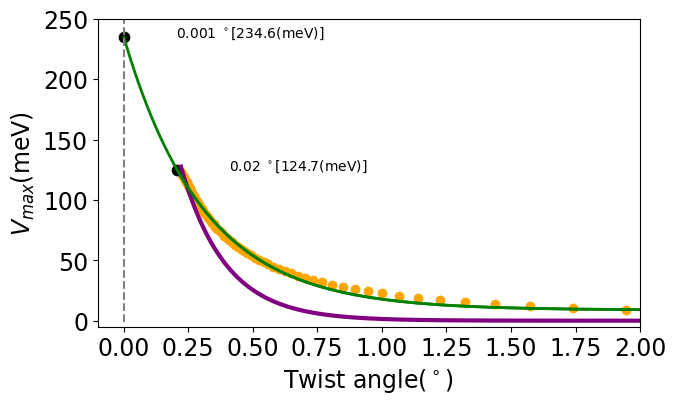

In [8]:

# print(cutha0.shape,cuttb0.shape)
sss=17
plt.figure(figsize=(7,4))
def fit_f(angle,a,b,c):
    return a*np.exp(b*angle)+c#f1+a2*np.exp(b2*angle**2)
from scipy.optimize import curve_fit
ang4=[]
for a2 in range(1,15001):
    ang4.append(alpha(a2,a2+1,a2+1,a2))
ang4=np.array(ang4)

ang5=[]
for a2 in range(1,80):
    ang5.append(alpha(a2,a2+1,a2+1,a2))
ang5=np.array(ang5)

b=a_lattice/ang2
GG=4*np.pi/(np.sqrt(3)*b)
plt.scatter(ang2,cutha0[:,-1]*10e4,color='orange')
# plt.scatter(ang1,cuttb0[:,-1]/10e3/4,color='black')
# p3=curve_fit(fit_f,ang1,cuttb0[:,-1]/10e3/4,p0=[0,-1,13])[0]
# plt.plot(ang4,fit_f(ang4,p3[0],p3[1],p3[2]),c="blue",lw=2)

plt.plot(ang2,np.exp(-GG*2)*(pmaxha[-1])/(2*diele)/10e20,color='purple',lw=3)
# p3=curve_fit(fit_f,ang2,np.exp(-GG*2)*(pmaxha[-1])/(2*diele)/10e20,p0=[0,-1,13])[0]
# plt.plot(ang4,fit_f(ang4,p3[0],p3[1],p3[2]),c="blue",lw=2)

p0=curve_fit(fit_f,ang2,cutha0[:,-1]*10e4,p0=[0,-1,13])[0]
plt.plot(ang4,fit_f(ang4,p0[0],p0[1],p0[2]),c="green",lw=2)

plt.vlines(0,-1,250,colors='grey',linestyles='--')
print(fit_f(ang4,p0[0],p0[1],p0[2])[-1])
print(fit_f(ang5,p0[0],p0[1],p0[2])[-1])

p2=curve_fit(fit_f,ang2,cutha0[:,-1]*10e4,p0=[0,-1,13])[0]
plt.plot(ang5,fit_f(ang5,p0[0],p0[1],p0[2]),c="green",lw=2)

plt.scatter(ang4[-1],fit_f(ang4,p0[0],p0[1],p0[2])[-1],s=55,c='black')
plt.text(ang4[-1]+0.2,fit_f(ang4,p0[0],p0[1],p0[2])[-1],"0.001 $^\circ$[234.6(meV)]")
plt.scatter(ang5[-1],fit_f(ang5,p0[0],p0[1],p0[2])[-1],s=55,c='black')
plt.text(ang5[-1]+0.2,fit_f(ang5,p0[0],p0[1],p0[2])[-1],"0.02 $^\circ$[124.7(meV)]")

plt.xlabel('Twist angle($^\circ$)',fontsize=sss)
plt.ylabel('$V_{max}$(meV)',fontsize=sss)
plt.xticks(fontsize=sss)
plt.yticks(fontsize=sss)
plt.ylim(-5,250)
plt.xlim(-0.1,2)
# plt.legend()

# print(np.min(ang5))


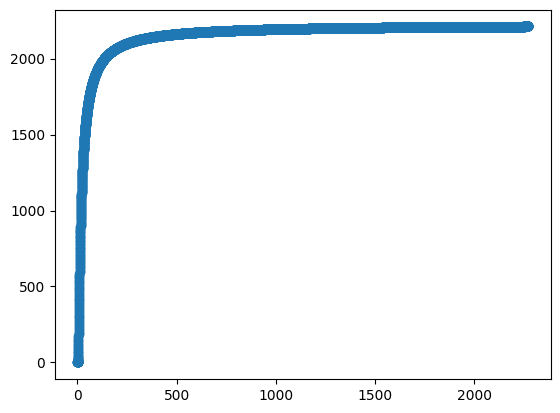

In [9]:
b=a_lattice/ang4
GG=4*np.pi/(np.sqrt(3)*b)
vr=np.exp(-GG*2)/epslion*2*10e12
plt.scatter(b,vr)


angle rang is 0.1464551877293594 to 1.435409424001952


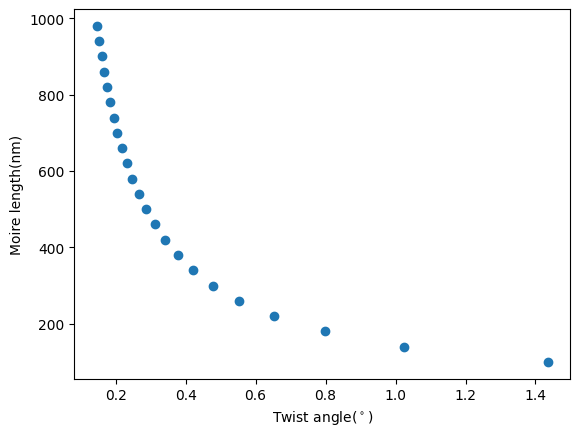

In [10]:
ll=np.arange(100,1000,40)
aa=np.arcsin(2.505/ll)
plt.scatter(np.rad2deg(aa),ll)
plt.xlabel('Twist angle($^\circ$)')
plt.ylabel('Moire length(nm)')
print(f'angle rang is {np.min(np.rad2deg(aa))} to {np.max(np.rad2deg(aa))}')

234.6148299202751


(-0.1, 1.0)

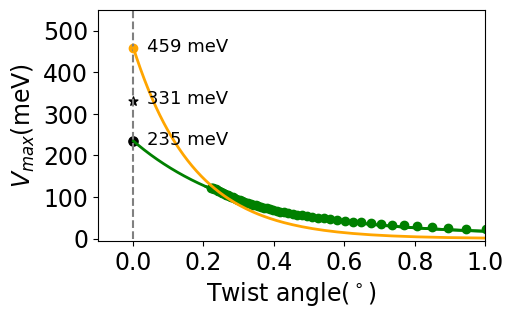

In [12]:

# print(cutha0.shape,cuttb0.shape)
sss=17
plt.figure(figsize=(5,3))
def fit_f(angle,a,b,c):
    return a*np.exp(b*angle)+c#f1+a2*np.exp(b2*angle**2)
from scipy.optimize import curve_fit
ang4=[]
for a2 in range(1,15001):
    ang4.append(alpha(a2,a2+1,a2+1,a2))
ang4=np.array(ang4)

ang5=[]
for a2 in range(1,80):
    ang5.append(alpha(a2,a2+1,a2+1,a2))
ang5=np.array(ang5)

b=a_lattice/ang2
GG=4*np.pi/(np.sqrt(3)*b)
plt.scatter(ang2,cutha0[:,-1]*10e4,color='green')
# plt.scatter(ang1,cuttb0[:,-1]/10e3/4,color='black')
# p3=curve_fit(fit_f,ang1,cuttb0[:,-1]/10e3/4,p0=[0,-1,13])[0]
# plt.plot(ang4,fit_f(ang4,p3[0],p3[1],p3[2]),c="blue",lw=2)
ss=13
# plt.plot(ang2,np.exp(-GG*2)*(pmaxha[-1])/(2*diele)/10e20,color='orange',lw=3)

p0=curve_fit(fit_f,ang2,cutha0[:,-1]*10e4,p0=[0,-1,13])[0]
plt.plot(ang4,fit_f(ang4,p0[0],p0[1],p0[2]),c="green",lw=2)

plt.vlines(0,-1,550,colors='grey',linestyles='--')
# print(fit_f(ang4,p3[0],p3[1],p3[2])[-1])
# print(fit_f(ang5,p0[0],p0[1],p0[2])[-1])

p2=curve_fit(fit_f,ang2,cutha0[:,-1]*10e4,p0=[0,-1,13])[0]
plt.plot(ang5,fit_f(ang5,p0[0],p0[1],p0[2]),c="green",lw=2)
p3=curve_fit(fit_f,ang2,np.exp(-GG*2)*(pmaxha[-1])/(2*diele)/10e20,p0=[0,-1,13])[0]
plt.plot(ang4,fit_f(ang4,p3[0],p3[1],p3[2]),c="orange",lw=2)
plt.text(ang4[-1]+0.04,fit_f(ang4,p3[0],p3[1],p3[2])[-1]-10,"459 meV",fontsize=ss)
plt.scatter(ang4[-1],fit_f(ang4,p3[0],p3[1],p3[2])[-1],c='orange')


plt.scatter(ang4[-1],fit_f(ang4,p0[0],p0[1],p0[2])[-1],s=44,c='black')
# plt.text(ang4[-1]+0.04,fit_f(ang4,p0[0],p0[1],p0[2])[-1]-10,"0.001 $^\circ$[234.6(meV)]")
plt.text(ang4[-1]+0.04,fit_f(ang4,p0[0],p0[1],p0[2])[-1]-10,"235 meV",fontsize=ss)
print(fit_f(ang4,p0[0],p0[1],p0[2])[-1])
# plt.scatter(ang5[-1],fit_f(ang5,p0[0],p0[1],p0[2])[-1],s=55,c='black')
# plt.text(ang5[-1]+0.2,fit_f(ang5,p0[0],p0[1],p0[2])[-1],"0.02 $^\circ$[124.7(meV)]")
plt.scatter(0,331,marker='*',c='black',s=44)
plt.text(0.04,324,"331 meV",fontsize=ss)
plt.xlabel('Twist angle($^\circ$)',fontsize=sss)
plt.ylabel('$V_{max}$(meV)',fontsize=sss)
plt.xticks(fontsize=sss)
plt.yticks(fontsize=sss)
plt.ylim(-5,550)
plt.xlim(-0.1,1)
# plt.legend()

# print(np.min(ang5))

